In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df1=pd.read_csv("/content/drive/MyDrive/MLT/i1.csv")
df2=pd.read_csv("/content/drive/MyDrive/MLT/i2.csv")

In [ ]:
#merging two datasets
df=df1.merge(df2,how="outer")

In [ ]:
df.shape

(15621, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [ ]:
df=df.drop(['Table No.','Server Name','Covers','Variation','HSN'],axis=1)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Category     15621 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.3+ MB


In [ ]:
a=df['Final Total'].sum()
print(a)

2397010.12


In [ ]:
b=df['Invoice No.'].nunique()
print(b)


4925


In [ ]:
df['Invoice No.'].count()


np.int64(15621)

In [ ]:
#avg spending of each
d=a/b
print(d)

486.70256243654825


In [ ]:
df.groupby('Item Name')['Qty.'].sum()

,Qty.
Item Name,
"1 Indian Combo - Welcome Drink, Chicken Dum Biriyani, Onion Raita, Chicken Gravy, Boiled Egg, Chicke",29.0
Aalu Gobi Masala,3.0
Aalu Mutter Masala,1.0
American Chopsey( Veg),1.0
Baby Corn 65,55.0
...,...
Vegetable Pepper Soup,50.0
Venila Milk Shake,28.0
Venilla Scoop,90.0


In [ ]:
df.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False)[0:5]


,Qty.
Item Name,
Mineral Water,1672.0
Chicken Biriyani With Raitha And Gravy,1453.0
Butter Naan,1046.0
Romali Roti (1 No),822.0
Lemon Soda,722.0


<BarContainer object of 15621 artists>

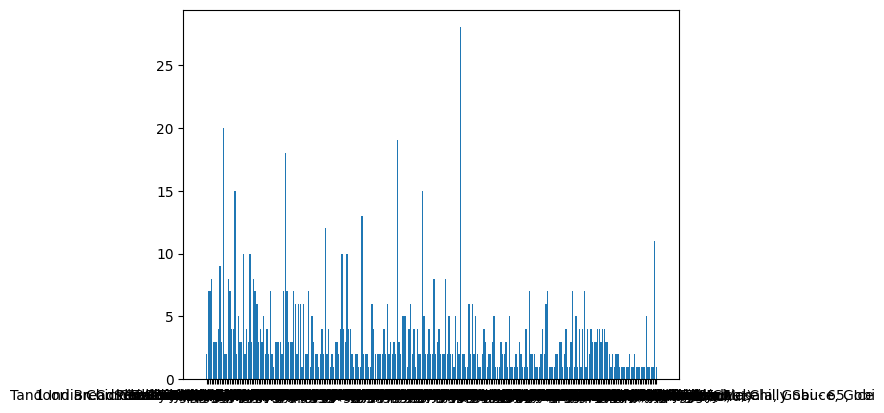

In [ ]:
#visualizing in bar plot
x=df['Item Name']
y=df['Qty.']
plt.bar(x,y)

In [ ]:
df.groupby('Item Name')['Final Total'].sum().sort_values(ascending=False).head(10)


,Final Total
Item Name,
Chicken Biriyani With Raitha And Gravy,240730.96
Chicken Fried Rice,119347.20
Butter Naan,65387.74
Thandoor Chicken Half,53185.83
Paneer Butter Masala,49581.22
Chicken Lolly Pop,48437.66
Chicken 65,48281.92
Pepper Tandoori Chicken ( Half ),45886.61
Dragon Chicken,44219.72


In [ ]:
df.plot(kind='bar')

In [ ]:
import seaborn as sns
sns.barplot(df)

In [ ]:
#sales on a specific date
df.groupby('Date')['Final Total'].sum().head(10)

,Final Total
Date,
2023-04-01,16601.56
2023-04-02,9780.50
2023-04-03,6643.86
2023-04-04,10898.96
2023-04-05,10624.98
2023-04-06,20182.16
2023-04-07,9544.46
2023-04-08,9369.70
2023-04-09,10928.92


In [ ]:
df.groupby('Date')['Final Total'].sum().loc['2023-09-15']

np.float64(21042.02)

In [ ]:
df[(df['Date']=='2023-09-15') & (df['Item Name']=='Chicken Noodles')] ['Qty.'].sum()

np.float64(7.0)

In [ ]:
j= df.groupby('Invoice No.')['Final Total'].sum()
j[j>2000]

#df[df['Final Total']>2000]['Invoice No.']

,Final Total
Invoice No.,
23499,2533.64
23508,2011.00
23637,5644.82
23718,3517.50
23827,22638.00
...,...
28014,3013.68
28126,2887.50
28145,4078.68


In [ ]:
j= df.groupby('Invoice No.')['Final Total'].sum()
j[j==2887.50]


,Final Total
Invoice No.,
28126,2887.5


In [ ]:
k= df.groupby(['Item Name','Qty.','Final Total'])['Invoice No.'].sum()
k[k==28145]


,,,Invoice No.
Item Name,Qty.,Final Total,
Chicken Chettinad Gravy,2.0,321.30,28145
Fish 65,2.0,376.12,28145
Garlic Naan,6.0,340.20,28145


wordcloud have 4 interpolation(used to avoid overlapping of words)

nearest -Used for pixelated images without smoothing.
bilinear - Used for smooth and simple image display.
bicubic -Used for high-quality smooth rendering.
spline16 - Used for moderate smooth image scaling.
spline36 - Used for very smooth high-quality scaling.
hanning -Used to reduce sharp edges and noise.
hamming - Used for smooth display while keeping details.
hermite - Used for soft and smooth image transitions.
kaiser -Used for balanced sharpness and smoothing.
quadric - Used for curved and smooth interpolation.
catrom -Used for sharper and clearer graphics.
gaussian - Used for blur-like smooth effects.
bessel -Used for smooth gradient preservation.
mitchell - Used for natural-looking image resizing.
sinc - Used for very accurate high-quality scaling.
lanczos - Used for professional sharp and smooth output.

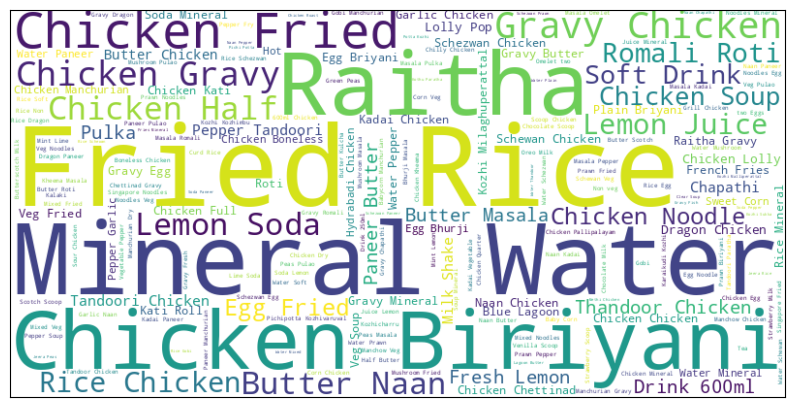

In [ ]:
from wordcloud import WordCloud
text= ' '.join(df['Item Name'].dropna().astype(str).values)
wordcloud= WordCloud(background_color='white',width=800,height=400).generate(text)

fig , ax =plt.subplots(figsize=(10,6))
ax.imshow(wordcloud , interpolation='bilinear')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

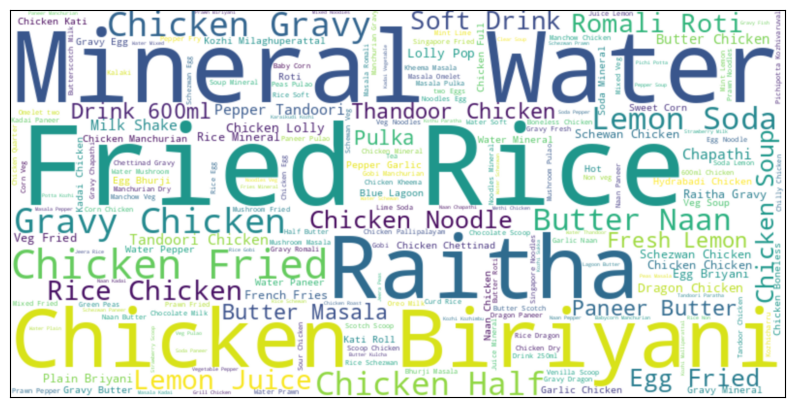

In [ ]:
from wordcloud import WordCloud
text= ' '.join(df['Item Name'].dropna().astype(str).values)
wordcloud= WordCloud(background_color='white',width=800,height=400).generate(text)

fig , ax =plt.subplots(figsize=(10,6))
ax.imshow(wordcloud , interpolation='bicubic')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

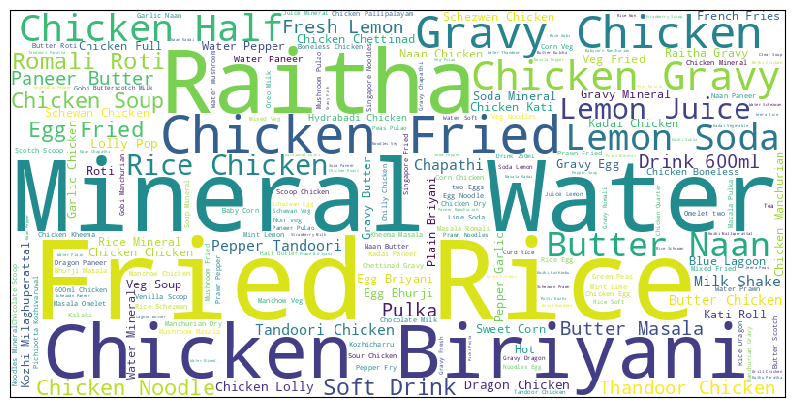

In [ ]:
from wordcloud import WordCloud
text= ' '.join(df['Item Name'].dropna().astype(str).values)
wordcloud= WordCloud(background_color='white',width=800,height=400).generate(text)

fig , ax =plt.subplots(figsize=(10,6))
ax.imshow(wordcloud , interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
plt.show()